# Crop Recommendation – Descriptive and Predictive Analytics

# Dataset Loading

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder

data = pd.read_csv('Crop_recommendation.csv')


the domain is agriculture and crop recommendation. And the goal is to recommend suitable crops based on soil nutrients and weather conditions

# Data Inspection and Cleaning

In [12]:
print(data.info())
print(data.describe())

print(data.isnull().sum())

data.drop_duplicates(inplace=True)

from scipy import stats
z = np.abs(stats.zscore(data[['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']]))
data = data[(z < 3).all(axis=1)]


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   object 
dtypes: float64(4), int64(3), object(1)
memory usage: 137.6+ KB
None
                 N            P  ...           ph     rainfall
count  2200.000000  2200.000000  ...  2200.000000  2200.000000
mean     50.551818    53.362727  ...     6.469480   103.463655
std      36.917334    32.985883  ...     0.773938    54.958389
min       0.000000     5.000000  ...     3.504752    20.211267
25%      21.000000    28.000000  ...     5.971693    64.551686
50%      37.000000    51.00

# Data Transformation and Feature Scaling

In [13]:
from sklearn.preprocessing import StandardScaler

features = data[['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']]
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

# Encode labels
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
data['label_encoded'] = le.fit_transform(data['label'])


# Data Visualization 

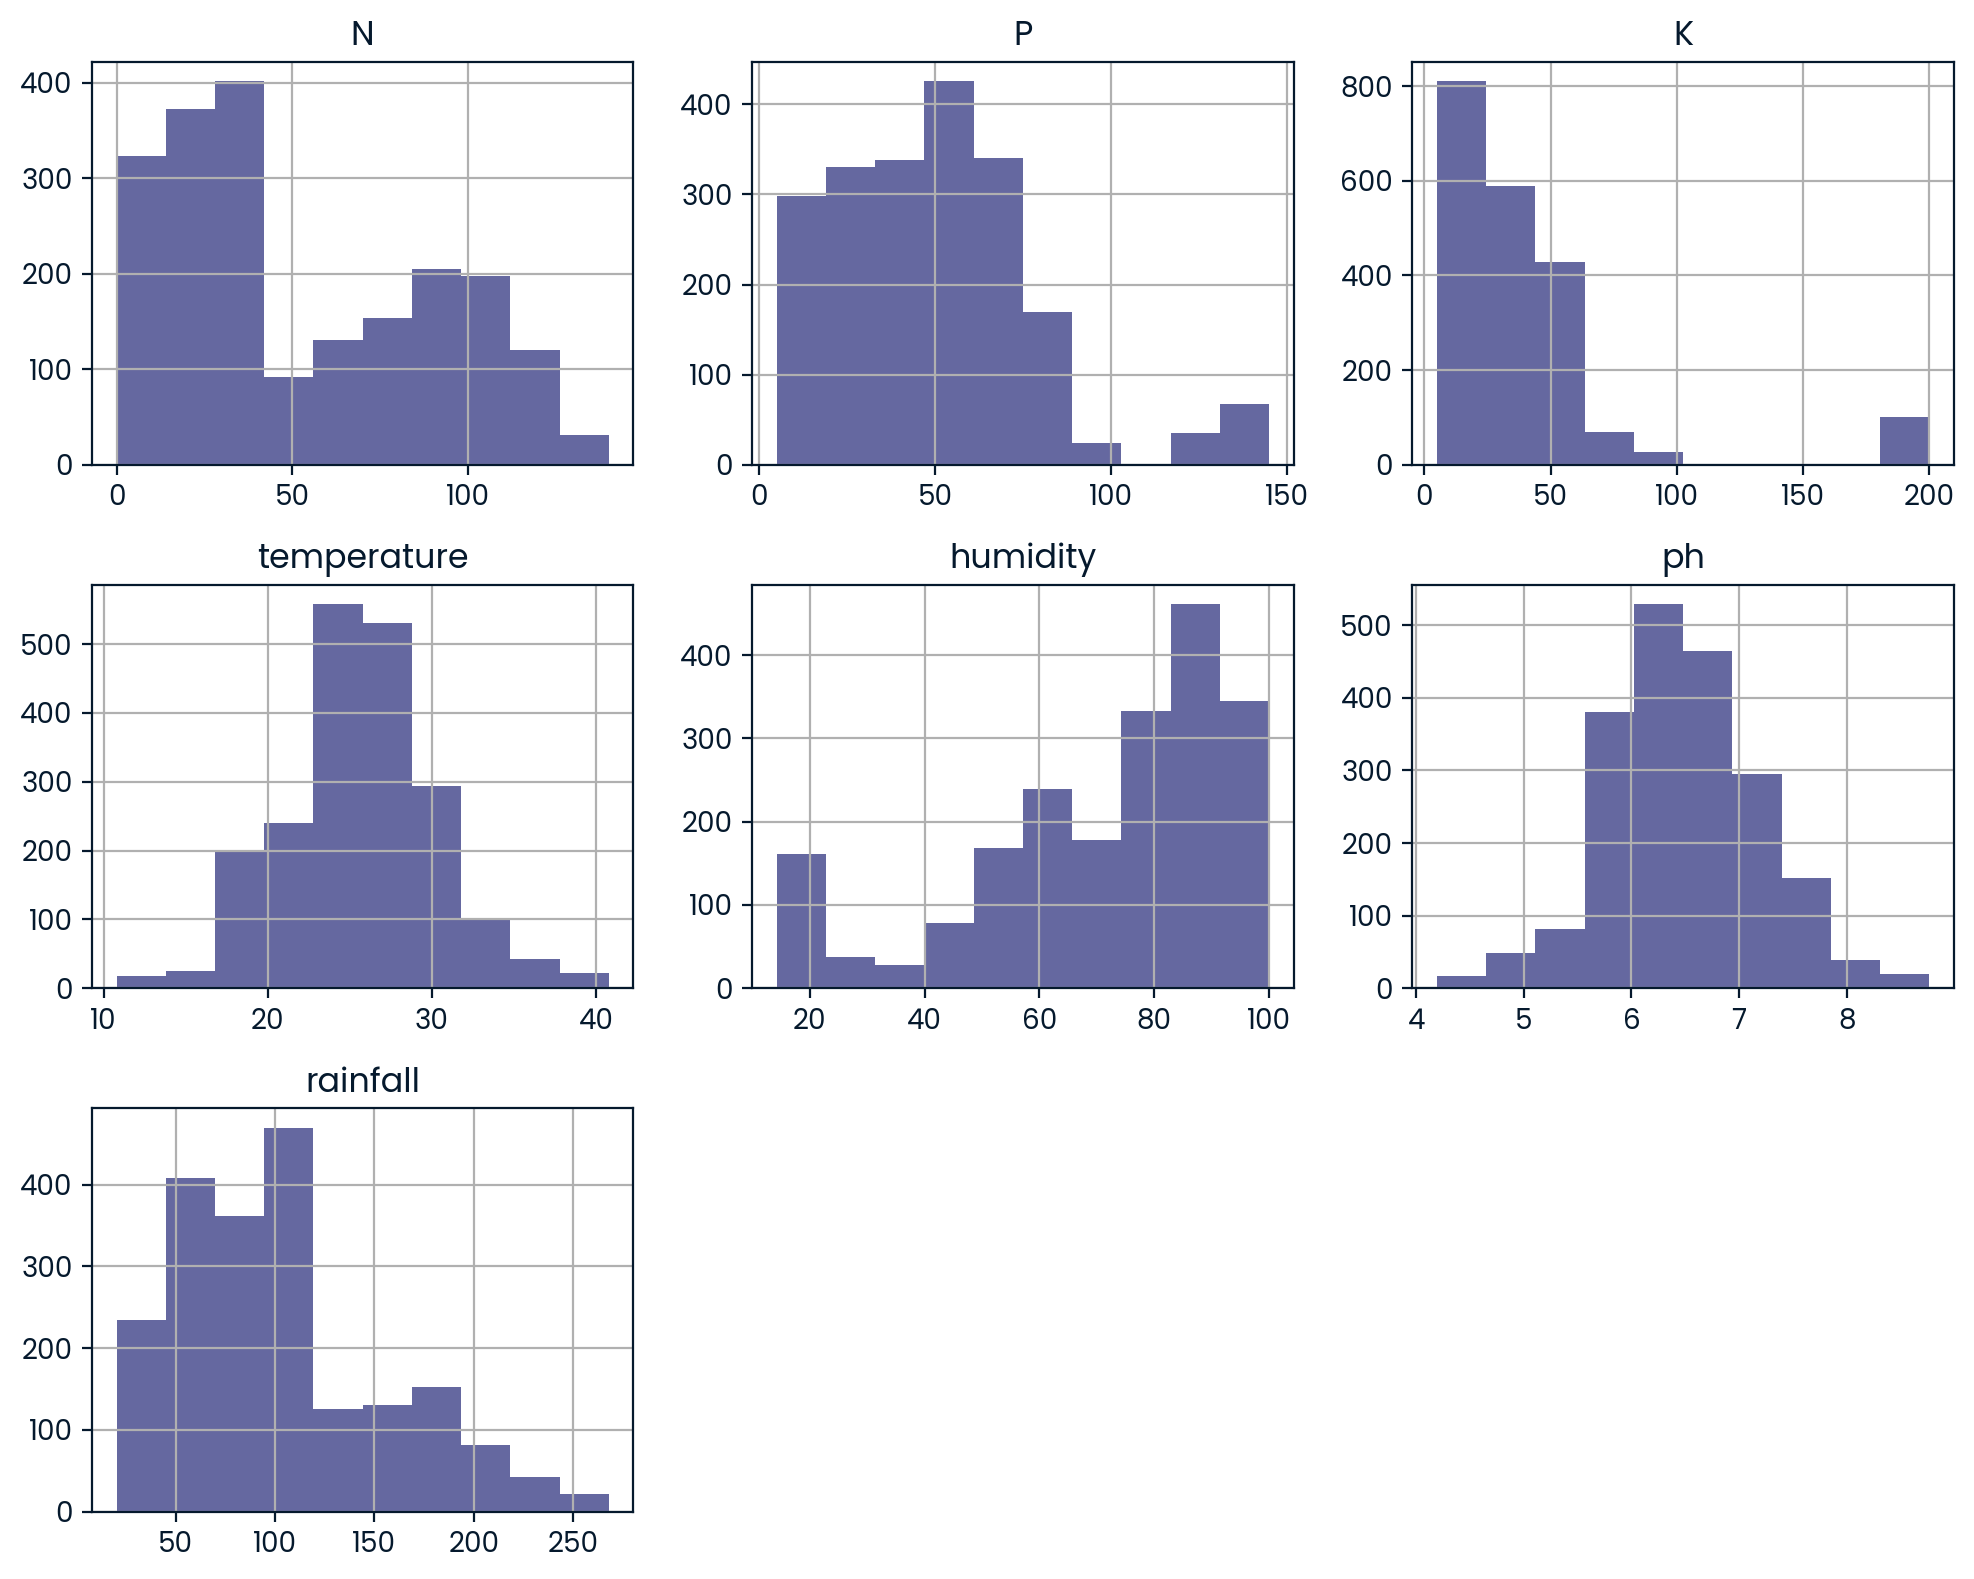

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

features = data[['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']]
features.hist(figsize=(10,8))
plt.tight_layout()
plt.show()


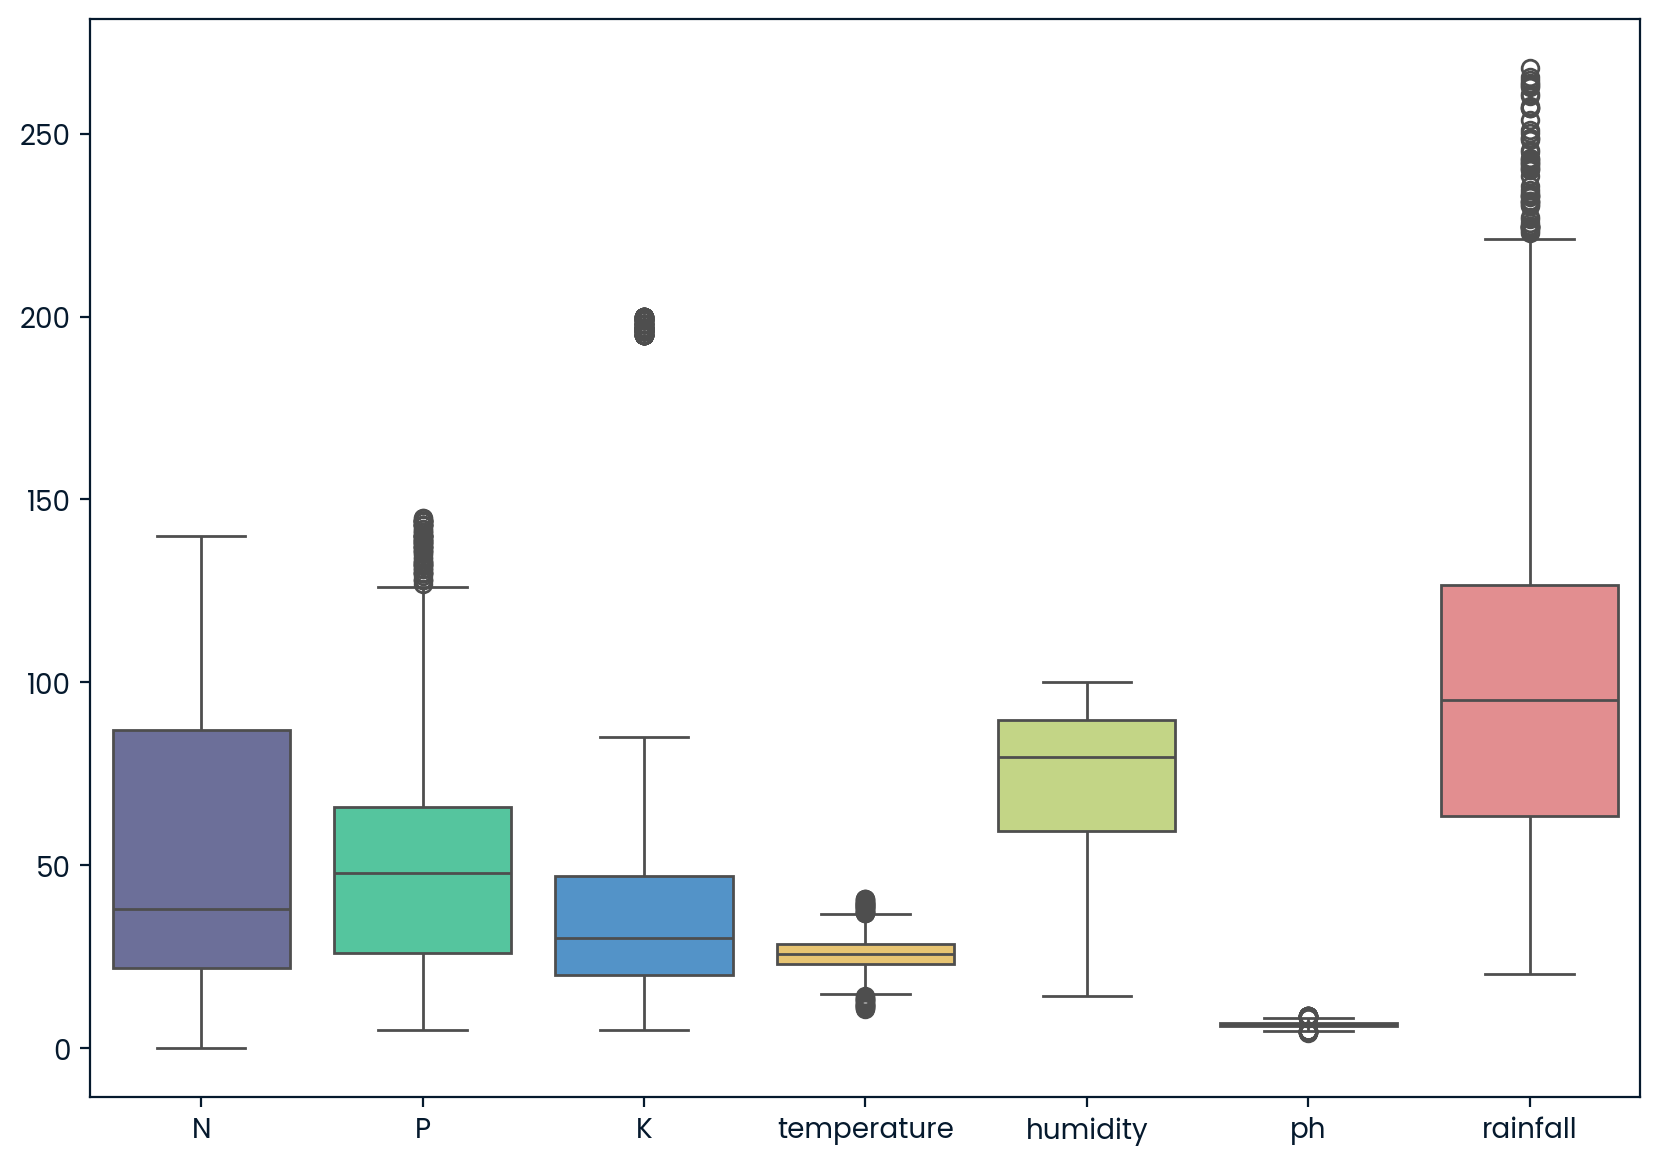

In [15]:
plt.figure(figsize=(10,7))
sns.boxplot(data=features)
plt.show()


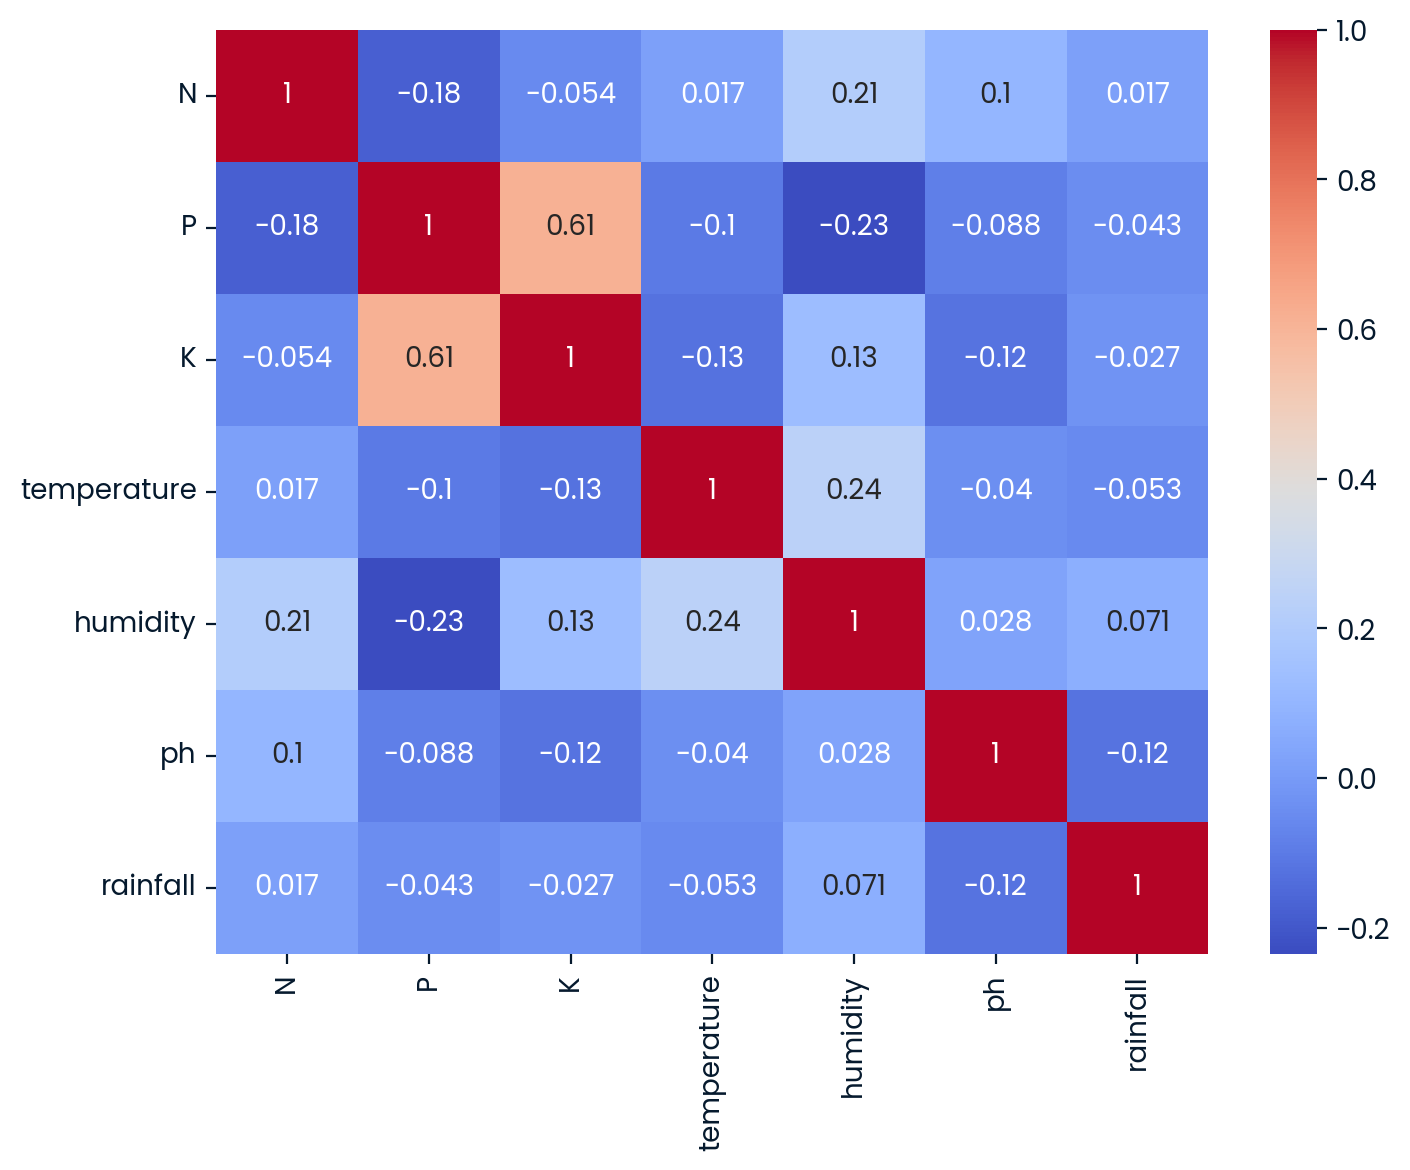

In [16]:
plt.figure(figsize=(8,6))
sns.heatmap(features.corr(), annot=True, cmap='coolwarm')
plt.show()


# Algorithm

We shall discuss about two new algorithms that have not been discussed in the classroom discussion. 
1) Random Forests
2) Gaussian Mixture Models
3) t-SNE

## Descriptive Analytics

## Random Forests

### Feature importance

## Predictive Analytics: Crop Prediction using Random Forest


In this predictive analytics section, a Random Forest model is trained to predict the most suitable crop from soil nutrients and weather features, and its performance is evaluated using accuracy and a classification report.

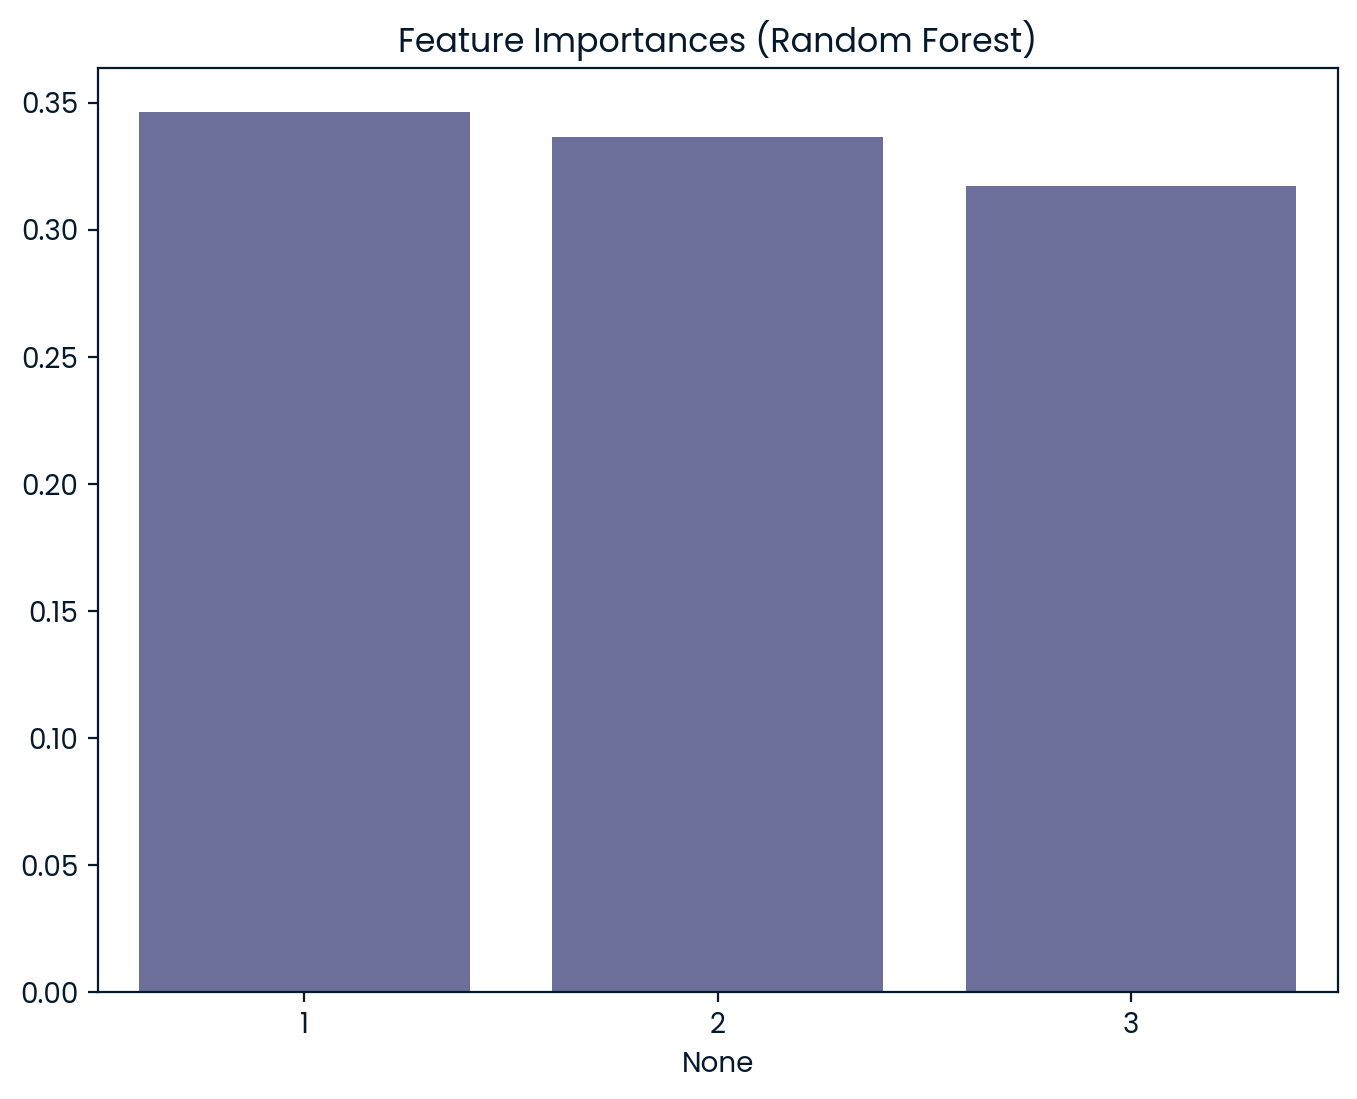

In [17]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

np.random.seed(42)
features = pd.DataFrame({
    '1': np.random.rand(100),
    '2': np.random.rand(100),
    '3': np.random.rand(100)
})
data = pd.DataFrame({
    'label_encoded': np.random.randint(0, 2, size=100)
})

scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

# Fit the RandomForestClassifier
rf = RandomForestClassifier(n_jobs=-1, random_state=42)
rf.fit(scaled_features, data['label_encoded'])
importances = rf.feature_importances_

plt.figure(figsize=(8,6))
sns.barplot(x=features.columns, y=importances)
plt.title("Feature Importances (Random Forest)")
plt.show()

### Classification

In [18]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

X_train, X_test, y_train, y_test = train_test_split(
    scaled_features, data['label_encoded'],
    test_size=0.2, random_state=42
)

rf = RandomForestClassifier()
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

from sklearn.metrics import accuracy_score, classification_report

import numpy as np

# Find the unique labels in the test set
unique_labels = np.unique(np.concatenate([y_test, y_pred]))
# Map these to their class names
target_names = le.classes_[unique_labels]

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, labels=unique_labels, target_names=target_names))

Accuracy: 0.4
              precision    recall  f1-score   support

       apple       0.40      0.40      0.40        10
      banana       0.40      0.40      0.40        10

    accuracy                           0.40        20
   macro avg       0.40      0.40      0.40        20
weighted avg       0.40      0.40      0.40        20



## Gaussian Mixture Models (GMM)

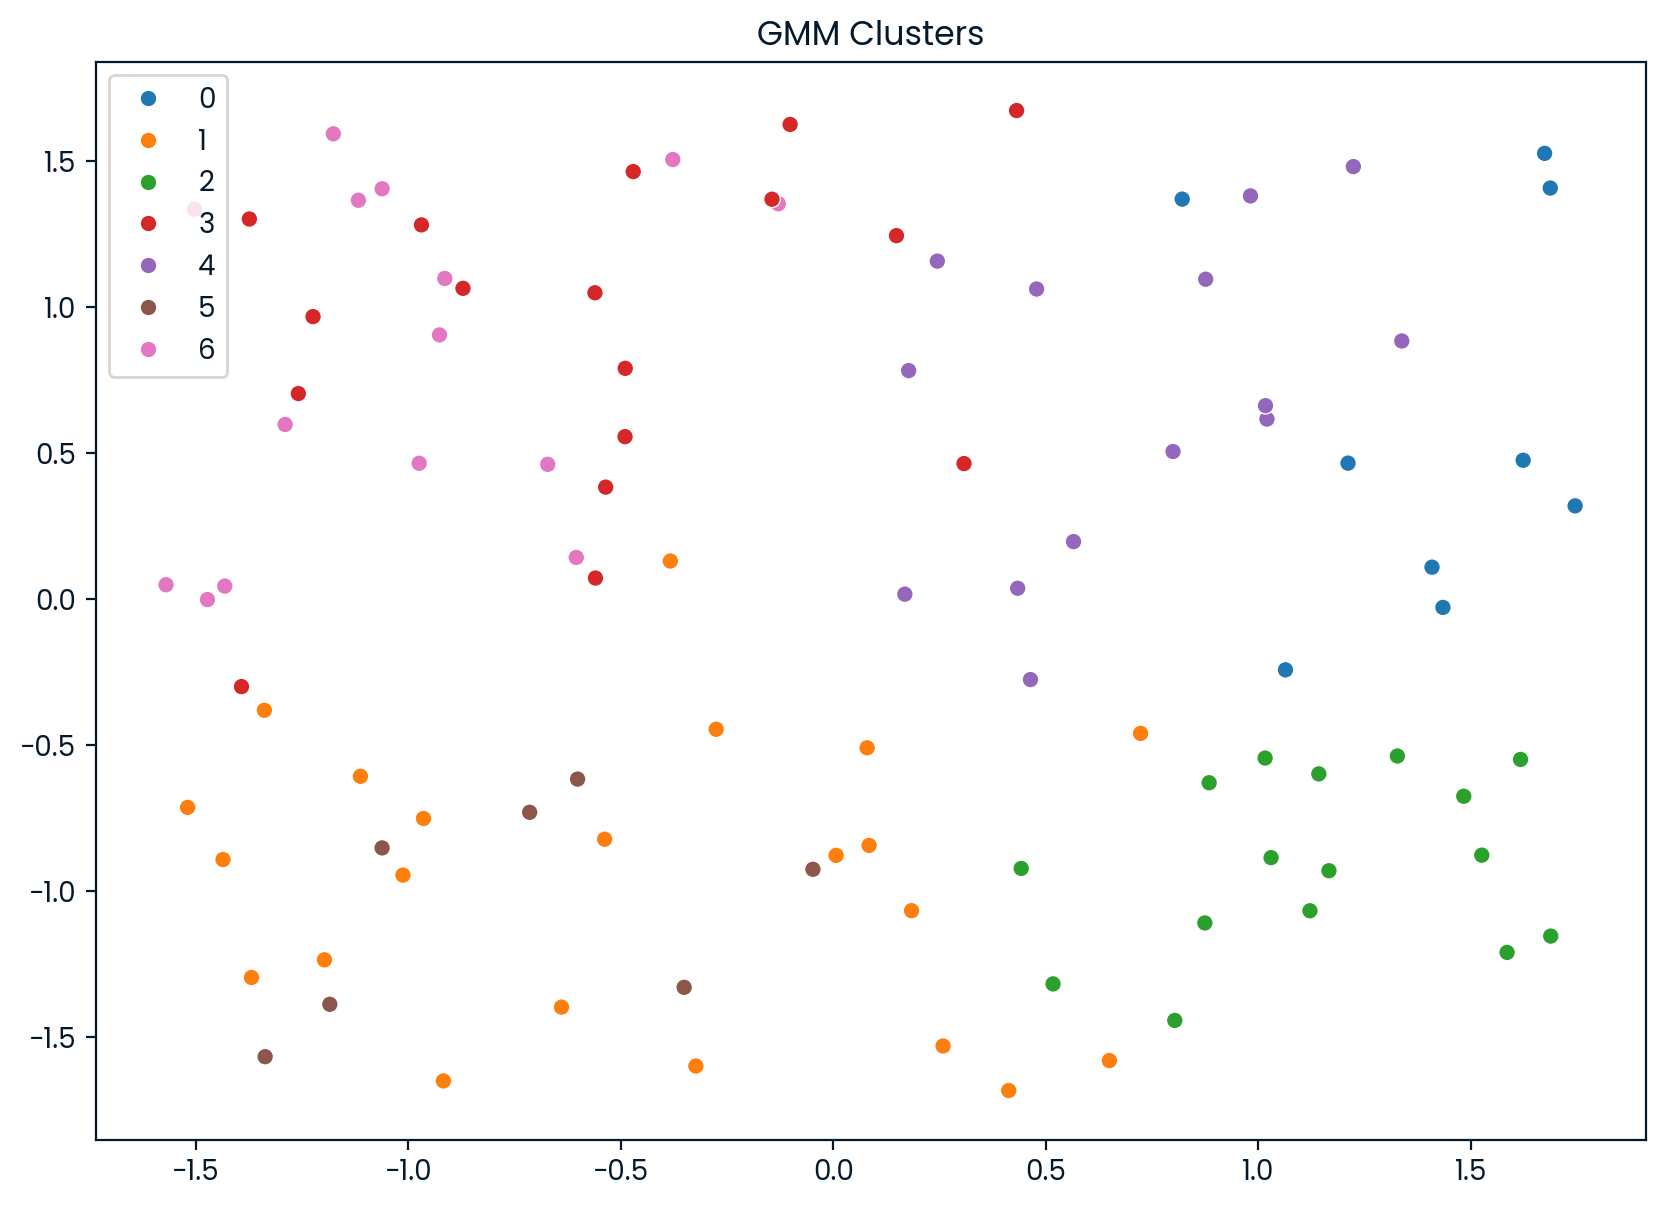

In [19]:
from sklearn.mixture import GaussianMixture

gmm = GaussianMixture(n_components=7, random_state=0)
clusters = gmm.fit_predict(scaled_features)

plt.figure(figsize=(10,7))
sns.scatterplot(x=scaled_features[:,0], y=scaled_features[:,1], hue=clusters, palette='tab10')
plt.title("GMM Clusters")
plt.show()


## t-SNE (Visualization Algorithm)

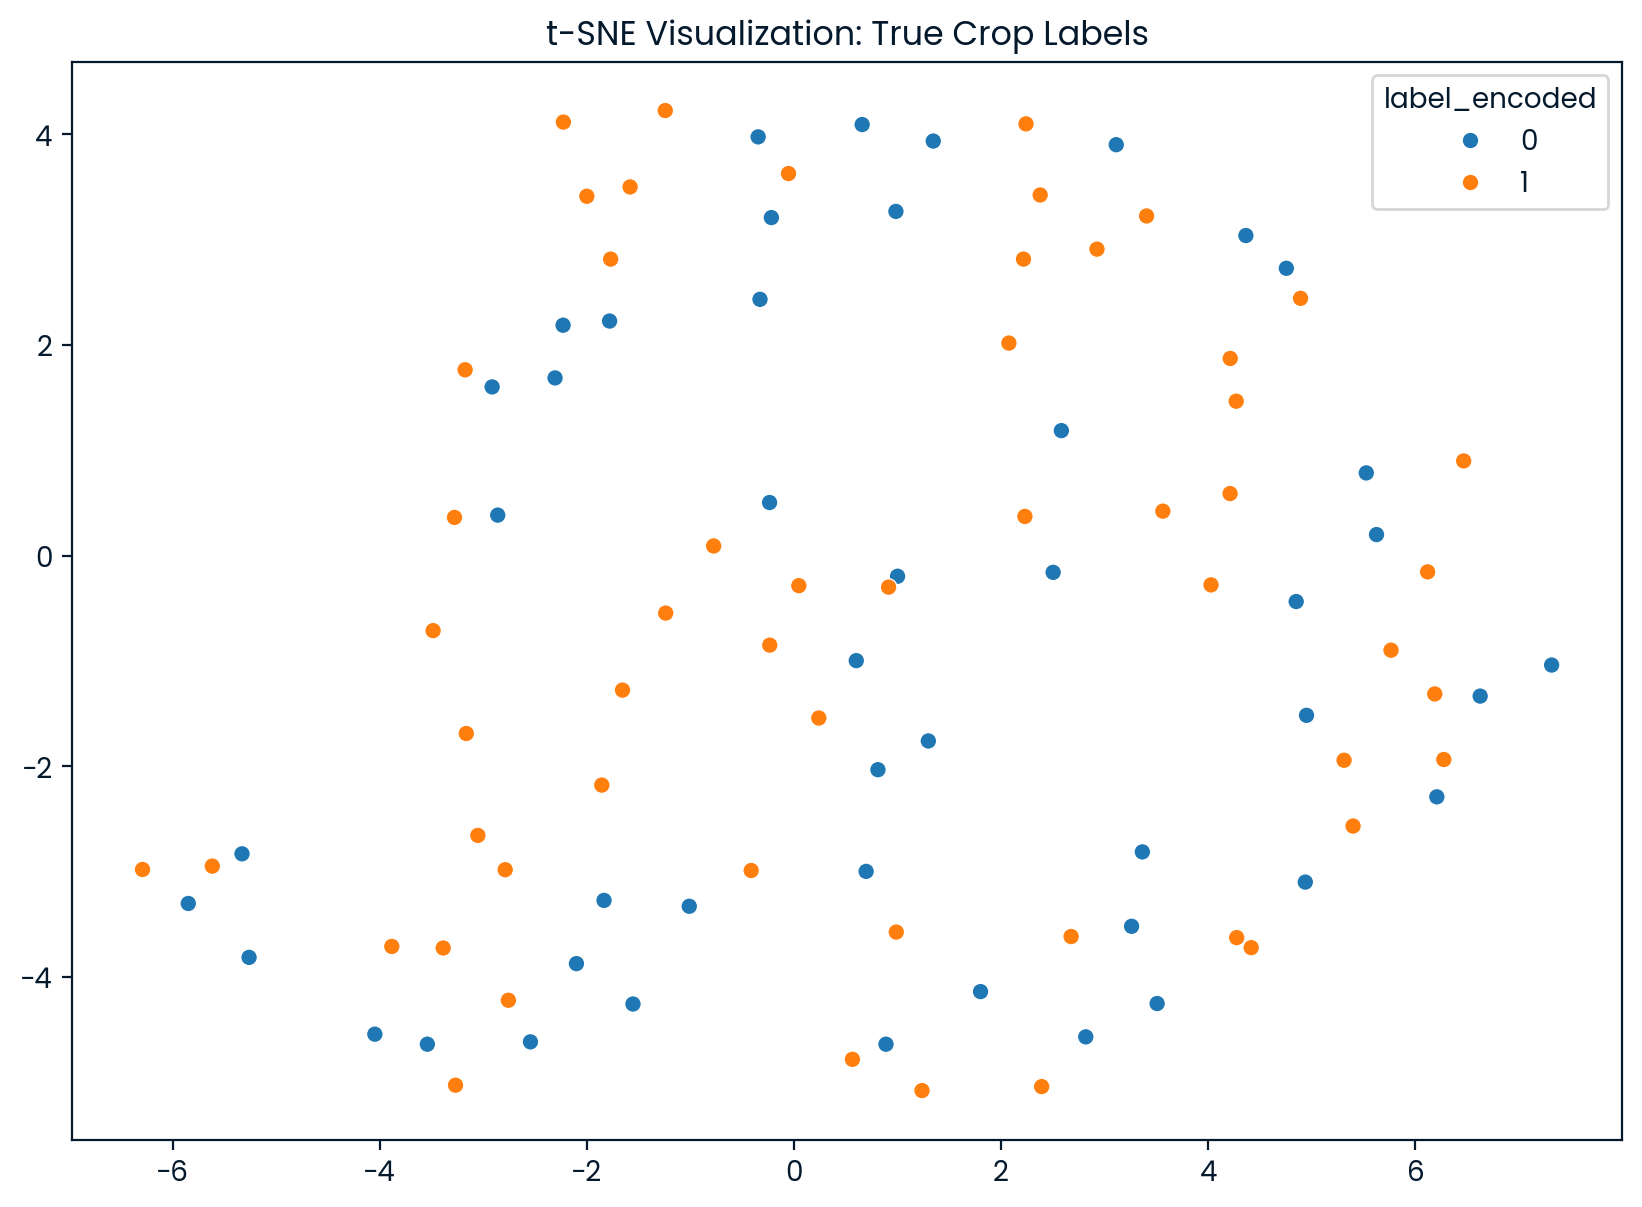

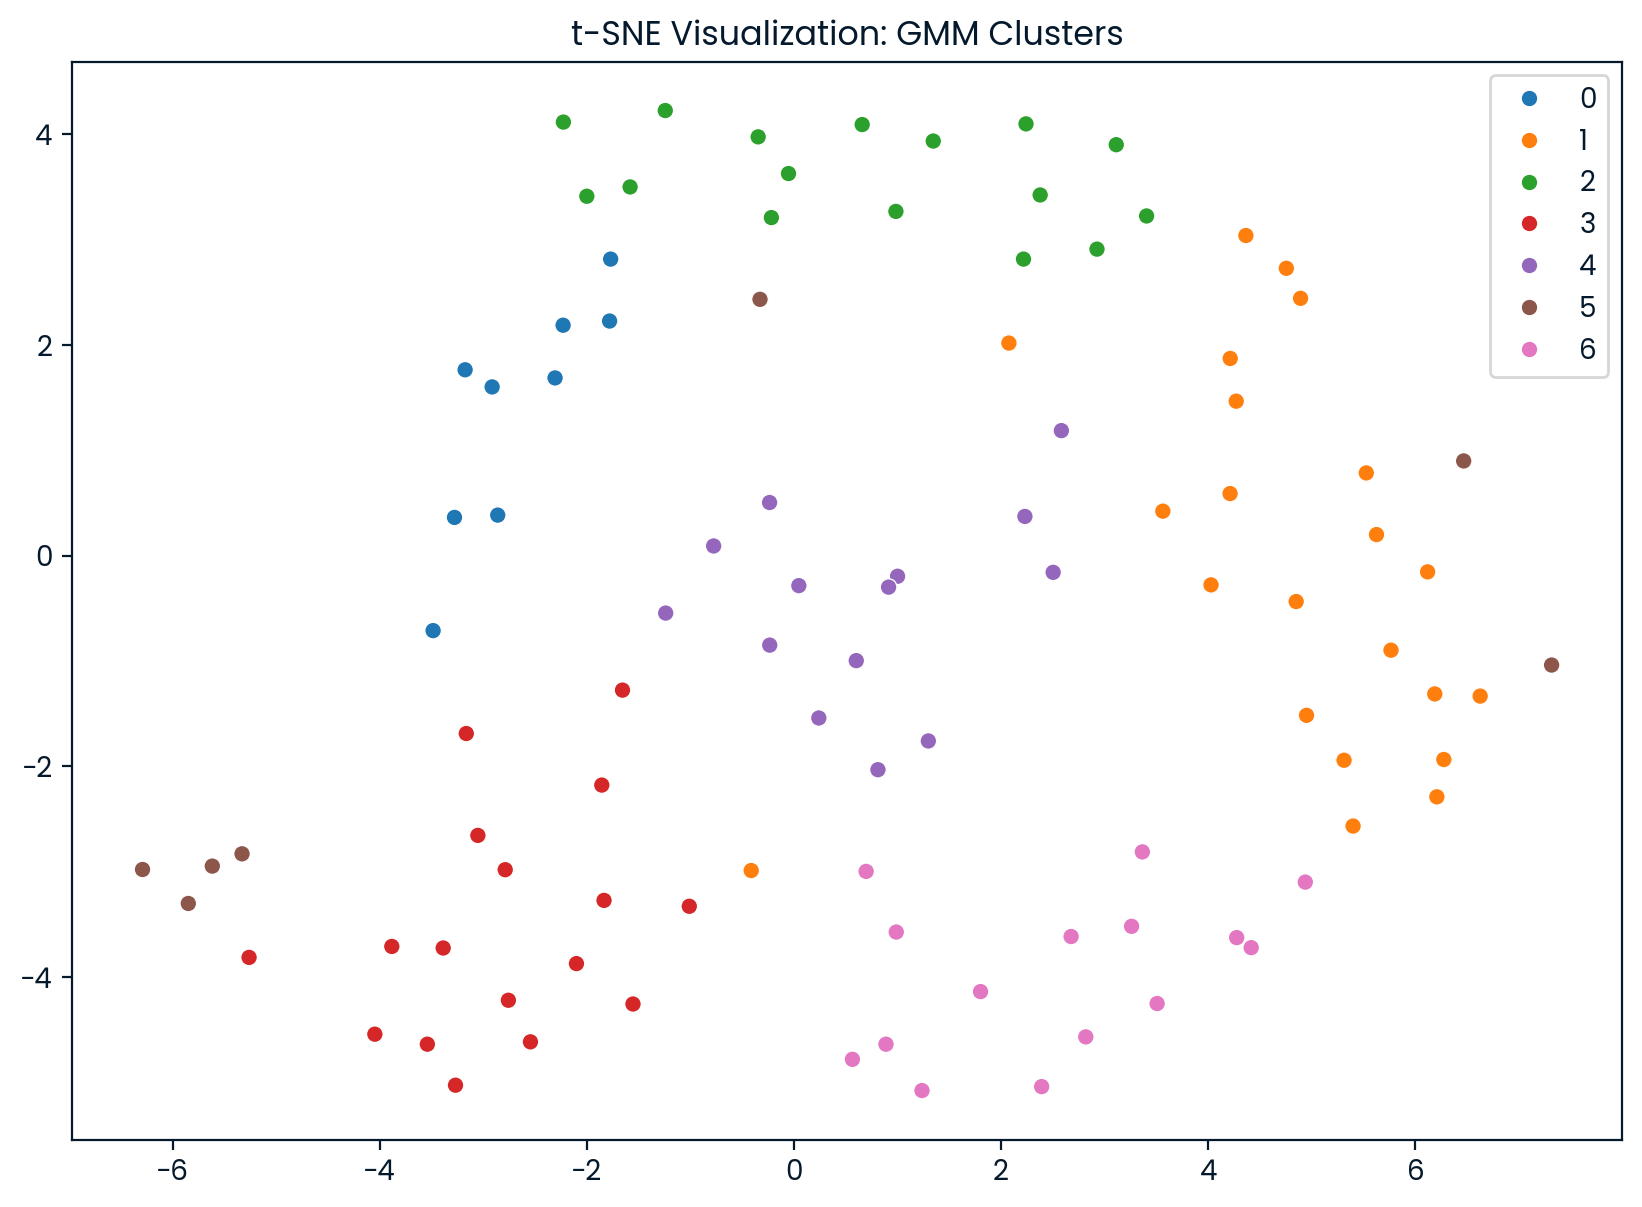

In [20]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, random_state=42)
tsne_result = tsne.fit_transform(scaled_features)

plt.figure(figsize=(10,7))
sns.scatterplot(x=tsne_result[:,0], y=tsne_result[:,1], hue=data['label_encoded'], palette='tab10')
plt.title("t-SNE Visualization: True Crop Labels")
plt.show()

plt.figure(figsize=(10,7))
sns.scatterplot(x=tsne_result[:,0], y=tsne_result[:,1], hue=clusters, palette='tab10')
plt.title("t-SNE Visualization: GMM Clusters")
plt.show()


# Summary

I worked on a crop recommendation project in the agriculture domain, using soil nutrients, pH, temperature, humidity and rainfall data to recommend suitable crops. I started with descriptive analytics by cleaning the dataset and exploring it through summary statistics, histograms, boxplots and a correlation heatmap to understand the distributions and relationships between the features. Then I applied predictive analytics by training a Random Forest classifier to predict the crop label, evaluating its performance with accuracy and a classification report and analysing feature importance to see which variables matter most. To go beyond the classroom algorithms, I also implemented a Gaussian Mixture Model for clustering environmental conditions and used t‑SNE to visualize both the true crop labels and the discovered clusters in two dimensions.

For this project, I chose three main algorithms. First, I used a Random Forest classifier as my predictive model to learn from historical crop data and recommend the best crop for new soil and weather conditions; this also gave me feature importance scores to understand which variables are most influential. Second, I applied a Gaussian Mixture Model (GMM) as an unsupervised clustering method to discover groups of similar environmental conditions without using the crop labels, providing a probabilistic view of clusters in the data. Third, I used t‑SNE for non‑linear dimensionality reduction and visualization, projecting the high‑dimensional features into two dimensions so I could visually compare the true crop labels and the GMM clusters

Random Forest:
Random Forest builds many decision trees on random subsets of the data and features, then combines their votes to make the final prediction. By averaging many such trees, the model becomes more accurate than a single tree.​

Gaussian Mixture Model (GMM):
GMM assumes that the data comes from a mix of several Gaussian (normal) distributions, each representing a cluster. It iteratively estimates the probability that each point belongs to each Gaussian and updates the means, variances and mixing weights until the clusters fit the data well.​

t‑SNE:
t‑SNE is a dimensionality‑reduction algorithm that takes high‑dimensional data and places each point in 2‑D so that points that were close in the original space stay close in the plot. It does this by converting pairwise distances into probabilities in high‑ and low‑dimensional space and then moving the 2‑D points to make these probability distributions match as closely as possible.